# MATPLOTLIB

- simple graphs:

    - (line)plot
    - bar
    - histogram
    - pie
    - scatterplot

- superposing of graphs:

    - label
    - legend

- formatting

    - title
    - axis
    - (x/y)ticks
    - labels
    - color
    - markers
    - figure

- sub-graphs

    - subplot
    - subplots
    - suptitle
    - tight_layout

- intermediate graphs:

    - add data/column labels

- images and array plots

    - imshow

- seaborn library


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


documentation:  
https://matplotlib.org/stable/gallery/index.html

exemples:  
https://matplotlib.org/stable/gallery/index.html

## data

In [2]:
iris = sns.load_dataset("iris")
iris.sample(6)

,sepal_length,sepal_width,petal_length,petal_width,species
108,6.7,2.5,5.8,1.8,virginica
128,6.4,2.8,5.6,2.1,virginica
139,6.9,3.1,5.4,2.1,virginica
142,5.8,2.7,5.1,1.9,virginica
98,5.1,2.5,3.0,1.1,versicolor
91,6.1,3.0,4.6,1.4,versicolor


In [3]:
poly = pd.DataFrame({"x":np.linspace(0, 10, 101)})
poly["y1"] = poly["x"]/5 - 0.5
poly["y2"] = poly["y1"]**2


# Simple graphs
- graphiques simples

## lineplot
- courbe
- nécessite
    - x et y comme type numérique
- exemple:
    - idéal pour afficher une progression dans le temps

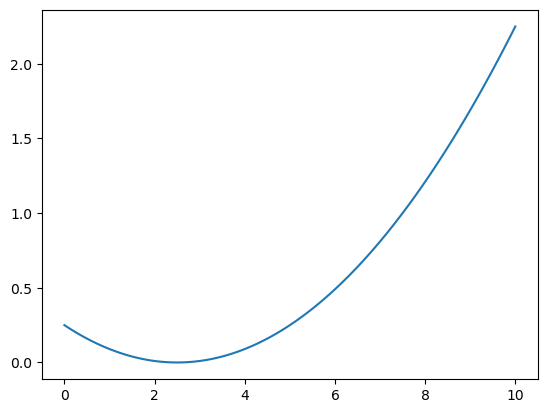

In [4]:

### plot= line-plot; plot(x,y,*args)

x = poly["x"]
y2 = poly["y2"]
plt.plot(x, y2) ## ajouter un simple graphique (courbe)


### afficher le graphique construit
plt.show() 

## barplot
- graphique en barre
- nécessite
    - "x" en catégorie/qualitatif
    - "height" en numérique

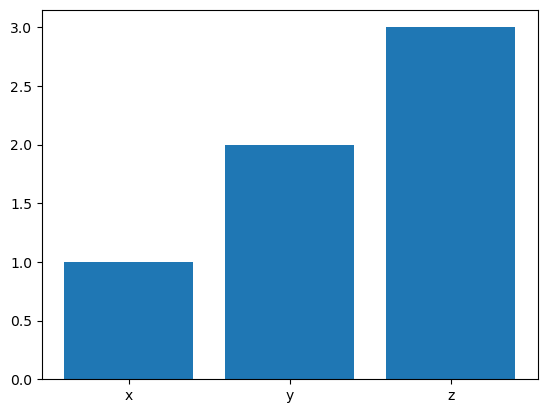

In [5]:
plt.bar(x=['x','y','z'],height=[1,2,3])
plt.show()

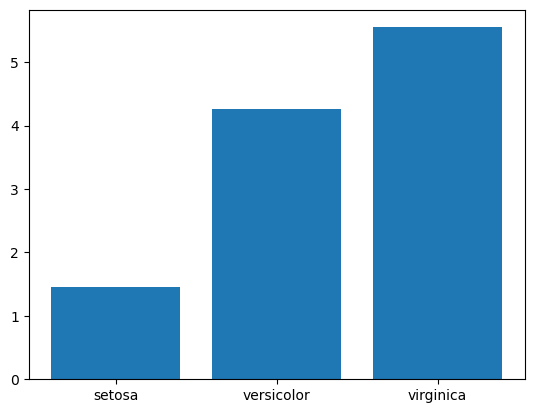

In [6]:
GB1 = iris.groupby("species",as_index=False).mean()

## afficher la moyenne de 'petal_length' groupé par 'species'
plt.bar(data=GB1, x='species',height='petal_length')
plt.show()

## histogram
- histogramme
- nécessite:
    - x en numérique
    - (bins) : compartiments/découpes des valeurs de 'x' en catégories contigu
- compte le nombre d'occurrences/lignes pour lequel les valeurs de 'x' se retrouve dans ces compartiments


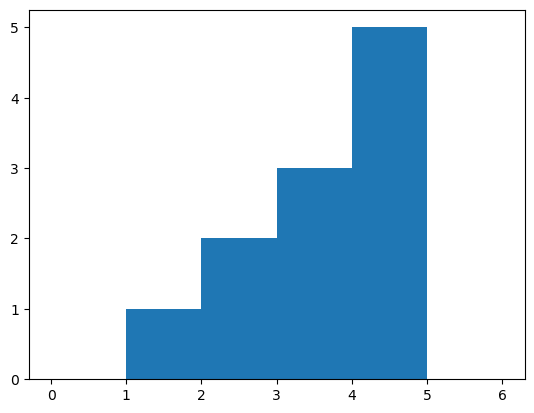

In [7]:
plt.hist(x=[1.1,2.1,2.2,3.1,3.2,3.3,4.1,4.2,4.3,4.4,4.5]
         ,bins=range(0,7,1) ## de 0 (inclu) à 1 exclu, 1 (inclu) à 2 (exclu), ...
        )
plt.show()

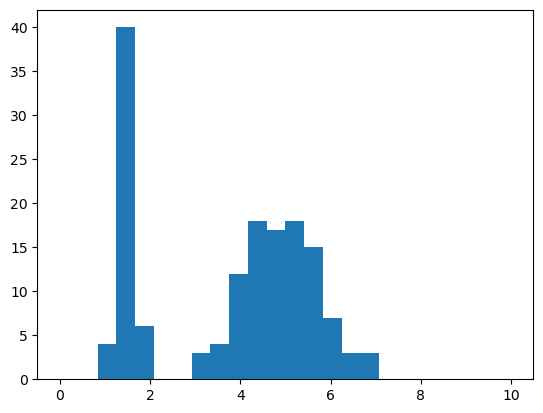

In [8]:
plt.hist(data = iris , x='petal_length', bins=np.linspace(0,10,25))
plt.show()

## pie
- graphique en secteurs, camembert
- simmilaire au 'barplot', mais vraiment utile que pour afficher des proportions
- nécessite:
    - x : ce qui indique la taille des secteur (proportionnel)
    - (label): nom des secteurs
    - (autopct): format des pourcentage à utiliser
        - exemple:
            - "%" + "1.2f" + "%%" = afficher 2 chiffes après la virgule
            - "%" + "1.0f" + "%%" = afficher 0 chiffes après la virgule

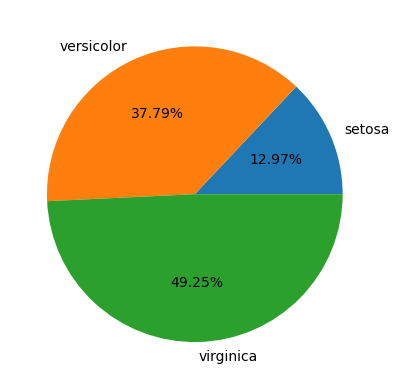

In [9]:
plt.pie(data=GB1, x='petal_length', labels='species', autopct='%1.2f%%')
plt.show()

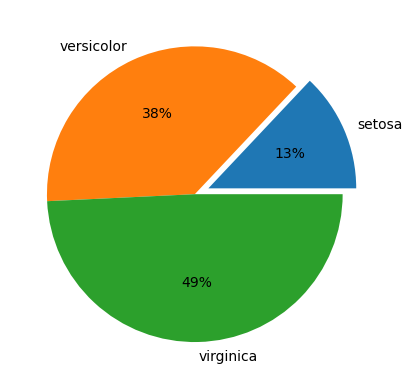

In [10]:
plt.pie(data=GB1, x='petal_length', labels='species', autopct='%1.0f%%'
        ,explode=(0.1,0,0) ## mise en évidence de la premiere entrée= decrochage du secteur
       ) 
plt.show()

## scatterplot
- nuage de points
- nécessite:
    - x et y comme numérique
- chaque point correspond à une ligne du dataset, avec une position (x,y) sur le graphique qui dépend des valeurs des colonnes x et y

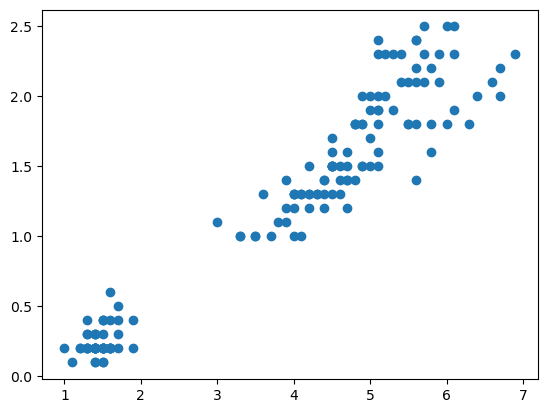

In [11]:
plt.scatter(data=iris, x='petal_length',y='petal_width')
plt.show()

# Superposing
- Superposition des couches de graphiques

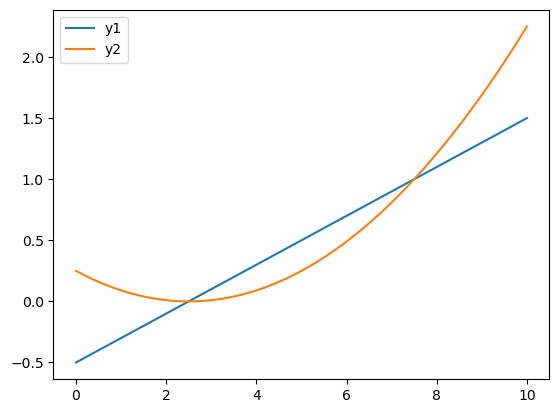

In [12]:

x = poly["x"]
y1 = poly["y1"]
y2 = poly["y2"]

plt.plot(x, y1, label='y1') ## label: nommer la couche
plt.plot(x, y2, label='y2') ## ajouter une couche par dessus la couche précédente

plt.legend() ## legende : afficher le nom de la couche (par défaut= dans le meilleur emplacement possible du graphique)
plt.show()

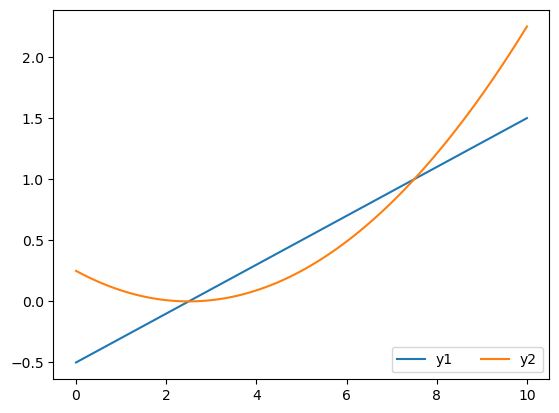

In [13]:

x = poly["x"]
y1 = poly["y1"]
y2 = poly["y2"]

plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2') 

plt.legend(loc = "lower right" ## imposer l'emplacement de la légende
           , ncol=2   ## imposer 2 colonnes
           )
plt.show()

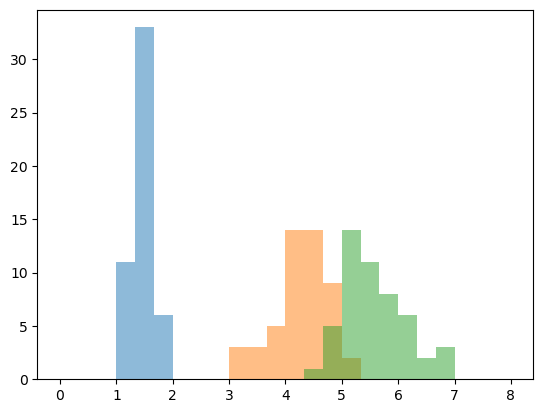

In [14]:
setosa = iris[iris["species"]=="setosa"]
versicolor = iris[iris["species"]=="versicolor"]
virginica = iris[iris["species"]=="virginica"]


bins = np.linspace(0,8,25)

plt.hist(data=setosa,x="petal_length"
         ,bins=bins
         ,alpha=0.5 ## ajouter de la transparence pour voir la supperposition
        ) 
plt.hist(data=versicolor,x="petal_length",bins=bins,alpha=0.5)
plt.hist(data=virginica,x="petal_length",bins=bins,alpha=0.5)


plt.show()

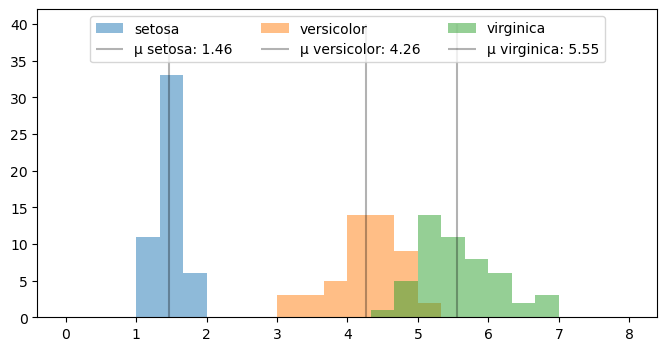

In [15]:

names = ["setosa","versicolor","virginica"]
bins = np.linspace(0,8,25)

col = "petal_length"

pars = {"alpha":0.5,"bins":bins,"x":col}

plt.figure(figsize=(8,4)) ## commencer image avec taille (8,4) pouces

for n in names:
    ### histogram
    df_n = iris[iris["species"]==n]
    plt.hist(data=df_n, **pars, label=n )

    ### vlines
    mean_n = df_n[col].mean().round(2)
    plt.vlines(mean_n, # x-pos
               ymin=0, 
               ymax=40,
               color='black', 
               label = f'µ {n}: {mean_n}',
               alpha = 0.3
              )
    
    

plt.legend(ncol=3, loc="upper center")
plt.show()

## Formatting
- formatage des graphiques:


### titre, axes, couleurs, ...  

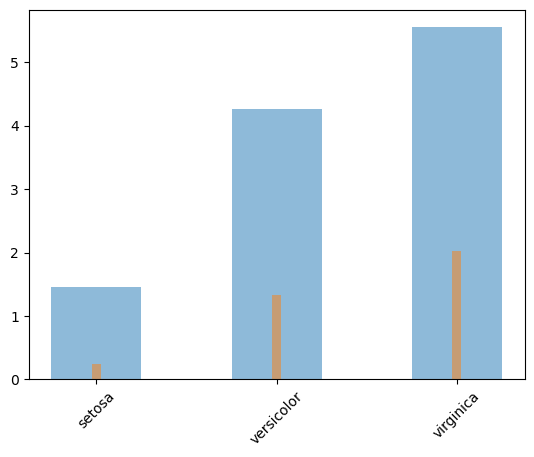

In [16]:
plt.bar(data=GB1
        ,x="species"
        ,height= "petal_length" 
        ,width=0.5 ## changer la largeur de chaque barre de cette couche
        ,alpha = 0.5 ## ajouter de la transparence pour voir la supperposition
       )
plt.bar(data=GB1
        ,x="species"
        ,height= "petal_width"
        ,width=0.05
        ,alpha = 0.5 
       )

plt.xticks(rotation=45) ## 45 degrées

plt.show()

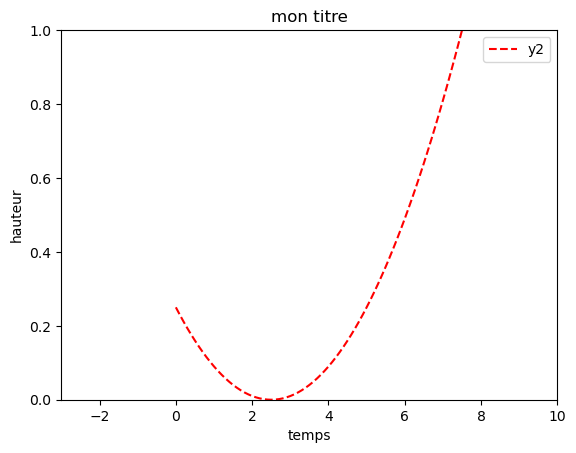

In [26]:
plt.title('mon titre') ## titre graphique
plt.plot(x, y2
         ,linestyle="--" ## style de ligne: tiret
         ,c="red"  ## c=couleur
         ,label='y2'
        ) 
### afficher legende
plt.legend() ## ce place automatiquement , le plus idéal

### nommer les axes
plt.xlabel('temps')
plt.ylabel('hauteur')

### modif des val min-max des axes
plt.axis([-3,10,0,1]) ## [xmin, xmax,ymin, ymax]

plt.show()

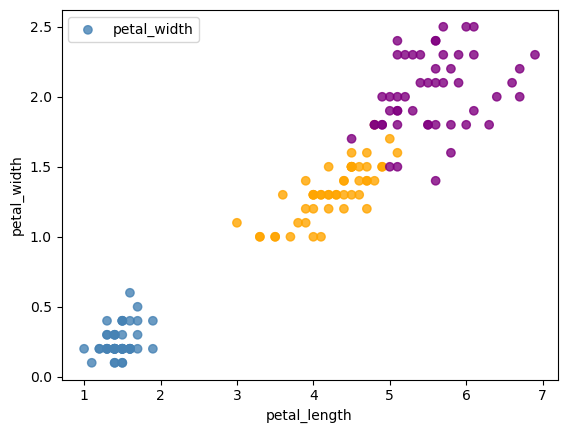

In [18]:
dict_color= {"setosa":"steelblue","versicolor":"orange","virginica":"purple"}

iris["color"]= iris["species"].map(dict_color)


plt.scatter(
    data = iris
    ,x="petal_length"
    ,y="petal_width"
    ,c="color"
    ,alpha= 0.8
)
plt.legend()
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.show()

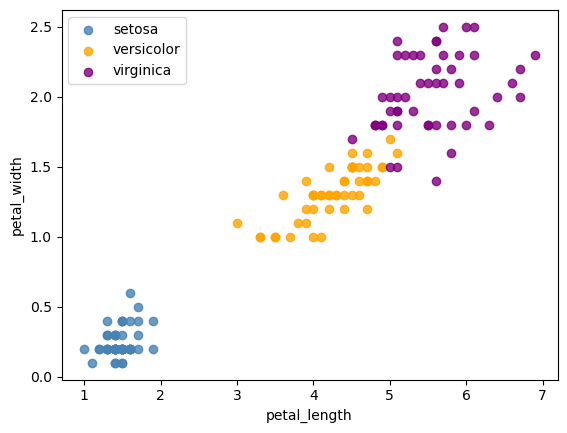

In [19]:
dict_color= {"setosa":"steelblue","versicolor":"orange","virginica":"purple"}




setosa = iris[iris["species"]=="setosa"]
versicolor = iris[iris["species"]=="versicolor"]
virginica = iris[iris["species"]=="virginica"]

plt.scatter(
    data = setosa
    ,x="petal_length"
    ,y="petal_width"
    ,c='steelblue'
    ,alpha= 0.8
    ,label="setosa"
)


plt.scatter(
    data = versicolor
    ,x="petal_length"
    ,y="petal_width"
    ,c='orange'
    ,alpha= 0.8
    ,label="versicolor"
)
plt.scatter(
    data = virginica
    ,x="petal_length"
    ,y="petal_width"
    ,c='purple'
    ,alpha= 0.8
    ,label="virginica"
)
plt.legend()
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.show()

### sous-graphiques
#### matlab-style

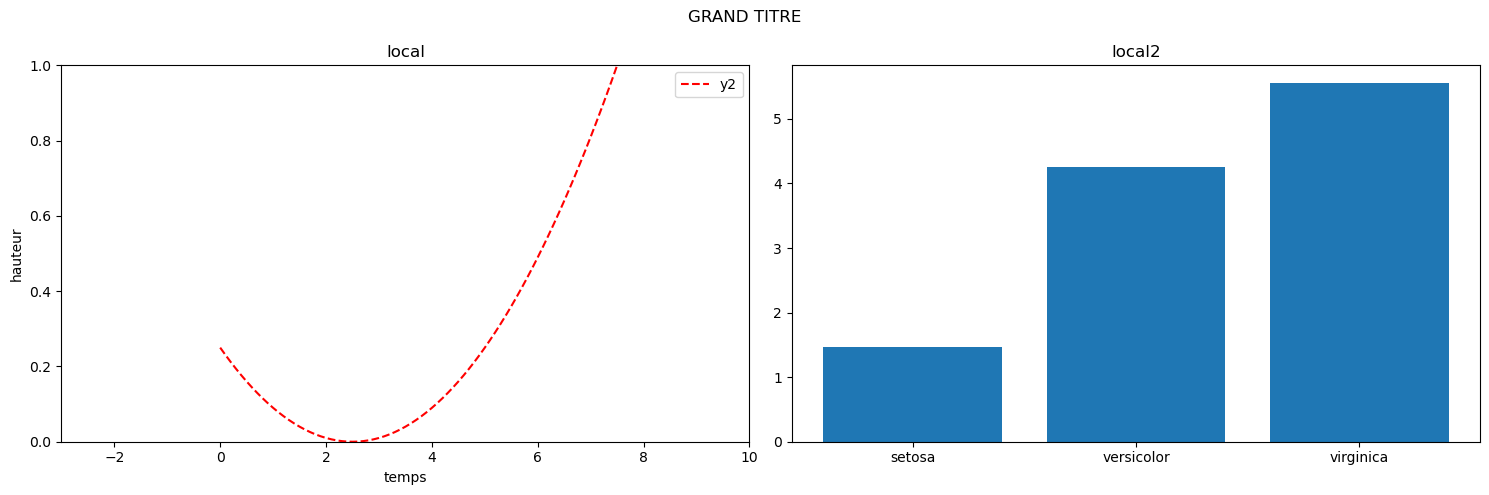

In [20]:
### alternative à la syntaxe suivante

### taille 
plt.figure(figsize=(15, 5)) # taille en pouces

### super titre
plt.suptitle('GRAND TITRE')

### je construit un sous-graphique, 1 row, 2 cols, 1er graphique
### toutes les modif vont s'appliquer à ce sous-graph
plt.subplot(1,2,1) 

plt.title('local') ## titre sous-graphique
plt.plot(x, y2
         ,linestyle="--" ## style de ligne: tiret
         ,c="red"  ## c=couleur
         ,label='y2'
        ) 
### afficher legende
plt.legend() ## ce place automatiquement , le plus idéal

### nommer les axes
plt.xlabel('temps')
plt.ylabel('hauteur')

### modif des val min-max des axes
plt.axis([-3,10,0,1]) ## [xmin, xmax,ymin, ymax]

### definir le 2ième sous-graphique
plt.subplot(1,2,2)
plt.title('local2')
plt.bar(data=GB1, x="species",height="petal_length")


### utiliser le tight_layout== ajouter padding pour eviter le chevauchement des graphiques
plt.tight_layout() 

### sauvegarder l'image en pdf (ou autre)
plt.savefig("demo.pdf") ## png, ...
plt.show() # toujours la dernière étape

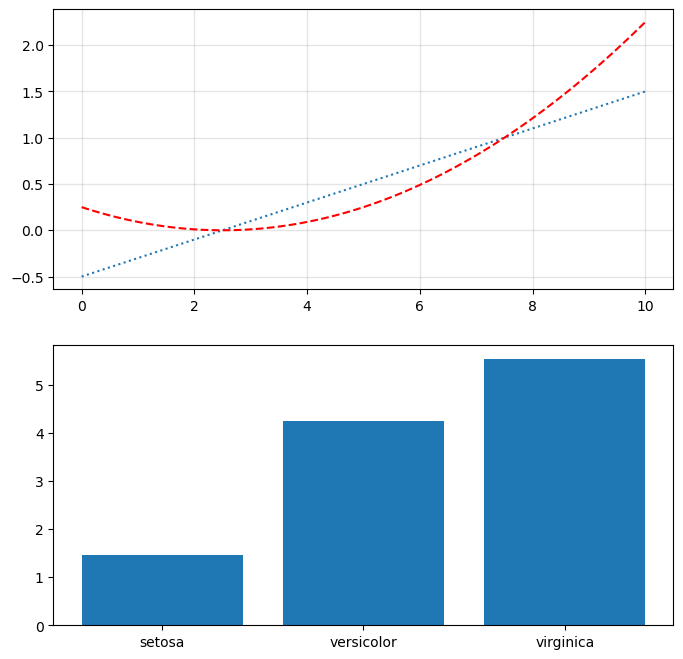

In [21]:
## fig= full graph
### ax = indexation sous-graphiques (emplacement)
### nrows = nbr lines de sous graphs
### cols = idem en colonnes

x = poly["x"]
y1 = poly["y1"]
y2 = poly["y2"]

### créer un graphique avec des caracteristiques


fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(8, 8))
ax[0].plot(x, y1, ":", label='y1')
ax[0].plot(x, y2
         ,linestyle="--" ## style de ligne: tiret
         ,c="red"  ## c=couleur
         ,label='y2'
        )

ax[1].bar(data=GB1, x="species",height="petal_length")

ax[0].grid(which='both', color='grey', linewidth=1, linestyle='-', alpha=0.2)

plt.show()

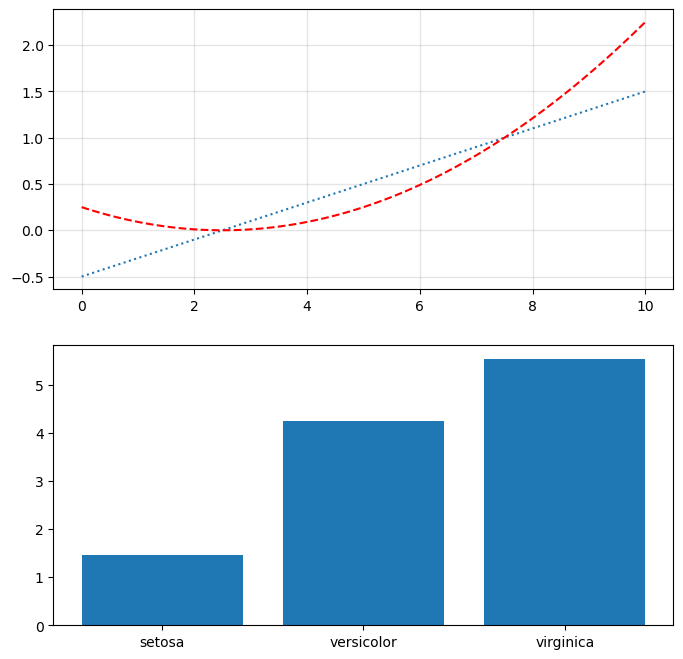

In [22]:
fig

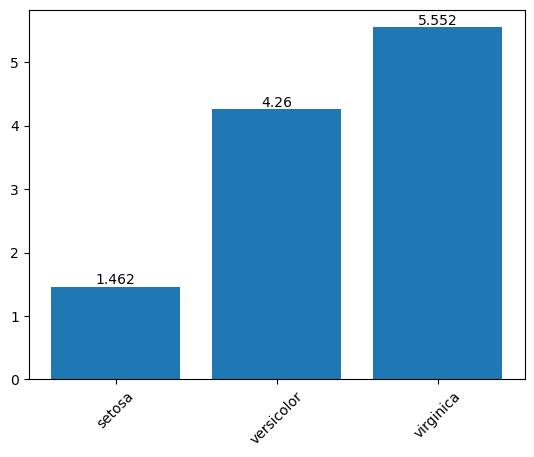

In [23]:
fig,ax = plt.subplots()

plt.bar(data=GB1, x="species",height="petal_length")

for bars in ax.containers:
    ax.bar_label(bars) # afficher la valeur d'une barre

plt.xticks(rotation=45)
plt.show()

### annotate inside graphs:
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html

# graph: show images


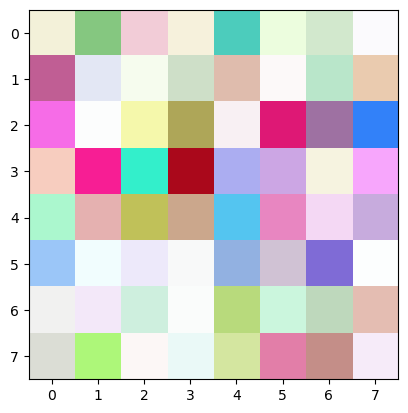

In [24]:
rdm_image = np.random.randint(0,255,(8,8,4)) # (... , ..., 4) : 4=(RED,GREEN,BLUE,ALPHA)

plt.imshow(rdm_image)
plt.show()

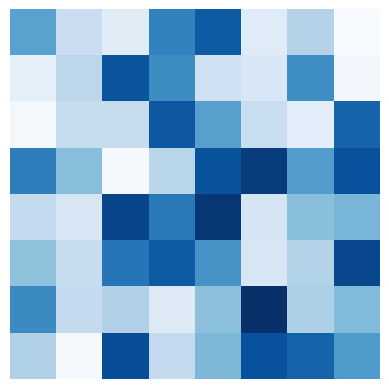

In [25]:
rdm_img2 = np.random.randint(0,255,(8,8)) ## noir et blanc


### color maps: https://matplotlib.org/stable/users/explain/colors/colormaps.html
plt.imshow(rdm_img2
           , cmap="Blues_r" ## cmap= "color_map" : "Greys","Greys_r" (reversed), "Blues", ...
          ) 
plt.axis("off") ## ne pas afficher les axes
plt.show()